In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("bank_data.csv")
df.columns = df.columns.str.strip().str.lower()


In [2]:
df.head()

,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cust_id                           8950 non-null   str    
 1   balance                           8950 non-null   float64
 2   balance_frequency                 8950 non-null   float64
 3   purchases                         8950 non-null   float64
 4   oneoff_purchases                  8950 non-null   float64
 5   installments_purchases            8950 non-null   float64
 6   cash_advance                      8950 non-null   float64
 7   purchases_frequency               8950 non-null   float64
 8   oneoff_purchases_frequency        8950 non-null   float64
 9   purchases_installments_frequency  8950 non-null   float64
 10  cash_advance_frequency            8950 non-null   float64
 11  cash_advance_trx                  8950 non-null   int64  
 12  purchases_trx    

In [4]:
df.describe()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
print(df.isnull().sum())

cust_id                               0
balance                               0
balance_frequency                     0
purchases                             0
oneoff_purchases                      0
installments_purchases                0
cash_advance                          0
purchases_frequency                   0
oneoff_purchases_frequency            0
purchases_installments_frequency      0
cash_advance_frequency                0
cash_advance_trx                      0
purchases_trx                         0
credit_limit                          1
payments                              0
minimum_payments                    313
prc_full_payment                      0
tenure                                0
dtype: int64


In [6]:
for col in df.columns:
    print(f"'{col}'") 

'cust_id'
'balance'
'balance_frequency'
'purchases'
'oneoff_purchases'
'installments_purchases'
'cash_advance'
'purchases_frequency'
'oneoff_purchases_frequency'
'purchases_installments_frequency'
'cash_advance_frequency'
'cash_advance_trx'
'purchases_trx'
'credit_limit'
'payments'
'minimum_payments'
'prc_full_payment'
'tenure'


In [7]:
# delete column cust_id because it is not useful for the analysis, and it is not a feature that can be used for clustering, because it is just an identifier for each customer and does not have any meaning in terms of the data.
df = df.drop("cust_id", axis=1)

In [8]:
df = df[df["credit_limit"].notnull()] # delete rows with null values in "credit_limit" column, cause it was only 1 row with null value

In [9]:
print(df.isnull().sum())

balance                               0
balance_frequency                     0
purchases                             0
oneoff_purchases                      0
installments_purchases                0
cash_advance                          0
purchases_frequency                   0
oneoff_purchases_frequency            0
purchases_installments_frequency      0
cash_advance_frequency                0
cash_advance_trx                      0
purchases_trx                         0
credit_limit                          0
payments                              0
minimum_payments                    313
prc_full_payment                      0
tenure                                0
dtype: int64


In [10]:
df["minimum_payments"] = df["minimum_payments"].fillna(df["minimum_payments"].median()) # fill null values in "minimum_payments" column with the median value of that column, because there are 313 rows with null values in that column, and it is better to fill them with the median value than to delete them, because it will not affect the distribution of the data as much as filling them with the mean value would do.

In [11]:
print(df.isnull().sum())

balance                             0
balance_frequency                   0
purchases                           0
oneoff_purchases                    0
installments_purchases              0
cash_advance                        0
purchases_frequency                 0
oneoff_purchases_frequency          0
purchases_installments_frequency    0
cash_advance_frequency              0
cash_advance_trx                    0
purchases_trx                       0
credit_limit                        0
payments                            0
minimum_payments                    0
prc_full_payment                    0
tenure                              0
dtype: int64


In [12]:
# created mask to find rows where there are values in "purchases" column but not in "purchases_trx" column, and vice versa, 
# because it is not possible to have values in one of those columns without having values in the other column, so those rows are 
# probably errors in the data and should be deleted.
mask = (((df["purchases"] > 0) & (df["purchases_trx"] == 0)) | ((df["purchases"] == 0) & (df["purchases_trx"] > 0))) 

In [13]:
mask.sum() # there are 6 rows that are inconsistent with the logic of the data, 
#so it is better to delete them than to try to fill them with some values, because it is not possible to know what values to fill them with.

np.int64(6)

In [14]:
df = df[~mask] # delete rows that match the mask

### Start with clusters after the cleaning of the data 

### first try with clusters 

In [15]:
cluster_data = df.copy()

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data) # scale the data to have mean 0 and standard deviation 1, because KMeans is sensitive to the scale of the data, and it is better to scale the data before applying KMeans, because it will give better results.

In [17]:
kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_3 = KMeans(n_clusters=3, random_state=42)

cluster_labels_2 = kmeans_2.fit_predict(scaled_data)
cluster_labels_3 = kmeans_3.fit_predict(scaled_data)

sc_2 = silhouette_score(scaled_data, cluster_labels_2)
sc_3 = silhouette_score(scaled_data, cluster_labels_3)

print("Silhouette score for model 1:", sc_2)
print("Inertia for model 1:", kmeans_2.inertia_)

print("Silhouette score for model 2:", sc_3)
print("Inertia for model 2:", kmeans_3.inertia_)

Silhouette score for model 1: 0.21029588648728173
Inertia for model 1: 127685.673864452
Silhouette score for model 2: 0.2505227268466617
Inertia for model 2: 111865.33124271384


In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_data)

In [19]:
df.head(10)

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.452292,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,1
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,0
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,1
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,1
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,1


In [20]:
# Examine the clusters
df.groupby("cluster").mean()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
cluster,,,,,,,,,,,,,,,,,
0,2232.571946,0.981447,4274.059521,2720.965977,1553.580162,461.708571,0.949010,0.668371,0.744373,0.063454,1.538524,56.537713,7742.538524,4159.136104,1224.689016,0.298143,11.922952
1,799.945810,0.835311,506.449122,253.666161,253.100646,330.830327,0.465613,0.132589,0.345573,0.068222,1.208306,8.673152,3274.129102,910.209450,523.424741,0.155913,11.480543
2,3986.531179,0.958807,383.023137,248.394567,134.692353,3869.064065,0.231902,0.110977,0.143744,0.447640,12.407152,5.579046,6666.878636,3002.056449,1787.110203,0.033503,11.346926


In [21]:
cluster_names = {
    0: "Power Spenders",
    1: "Everyday Users",
    2: "Cash Advance Users",
    3: "Low Spenders"}

df["customer_segment"] = df["cluster"].map(cluster_names)

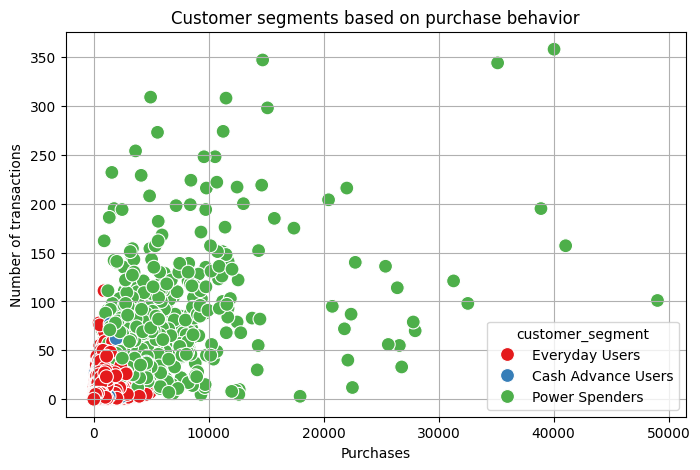

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="purchases",
    y="purchases_trx",
    hue="customer_segment",
    palette="Set1",
    s=100
)

plt.title("Customer segments based on purchase behavior")
plt.xlabel("Purchases")
plt.ylabel("Number of transactions")
plt.grid(True)
plt.show()

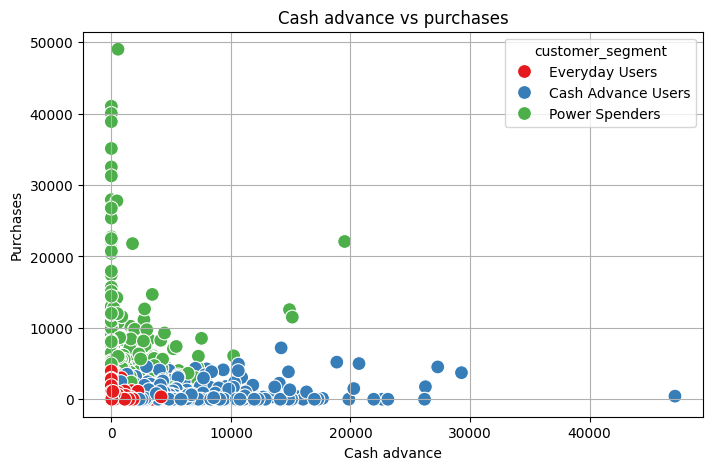

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="cash_advance",
    y="purchases",
    hue="customer_segment",
    palette="Set1",
    s=100
)

plt.title("Cash advance vs purchases")
plt.xlabel("Cash advance")
plt.ylabel("Purchases")
plt.grid(True)
plt.show()

In [24]:
df.groupby("customer_segment").mean()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure,cluster
customer_segment,,,,,,,,,,,,,,,,,,
Cash Advance Users,3986.531179,0.958807,383.023137,248.394567,134.692353,3869.064065,0.231902,0.110977,0.143744,0.447640,12.407152,5.579046,6666.878636,3002.056449,1787.110203,0.033503,11.346926,2.0
Everyday Users,799.945810,0.835311,506.449122,253.666161,253.100646,330.830327,0.465613,0.132589,0.345573,0.068222,1.208306,8.673152,3274.129102,910.209450,523.424741,0.155913,11.480543,1.0
Power Spenders,2232.571946,0.981447,4274.059521,2720.965977,1553.580162,461.708571,0.949010,0.668371,0.744373,0.063454,1.538524,56.537713,7742.538524,4159.136104,1224.689016,0.298143,11.922952,0.0


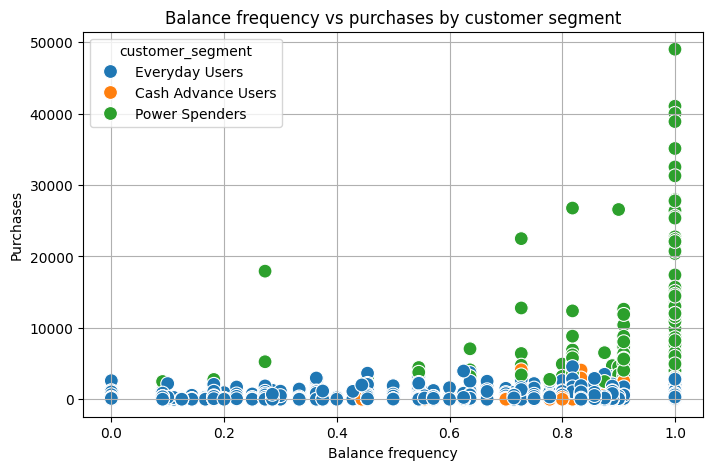

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="balance_frequency",
    y="purchases",
    hue="customer_segment",
    s=100
)

plt.title("Balance frequency vs purchases by customer segment")
plt.xlabel("Balance frequency")
plt.ylabel("Purchases")
plt.grid(True)
plt.show()

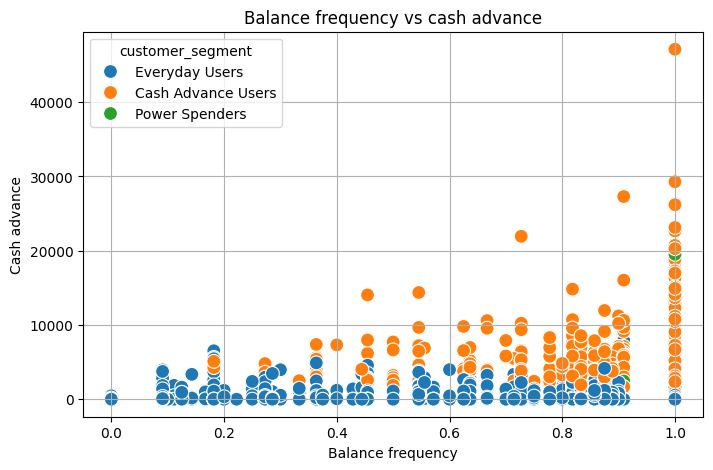

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="balance_frequency",
    y="cash_advance",
    hue="customer_segment",
    s=100
)

plt.title("Balance frequency vs cash advance")
plt.xlabel("Balance frequency")
plt.ylabel("Cash advance")
plt.grid(True)
plt.show()

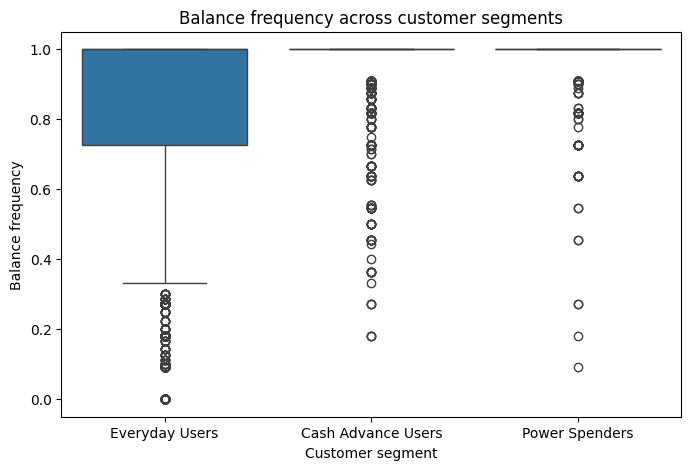

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="customer_segment",
    y="balance_frequency"
)

plt.title("Balance frequency across customer segments")
plt.xlabel("Customer segment")
plt.ylabel("Balance frequency")
plt.show()

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

df["pca1"] = pca_data[:, 0]
df["pca2"] = pca_data[:, 1]

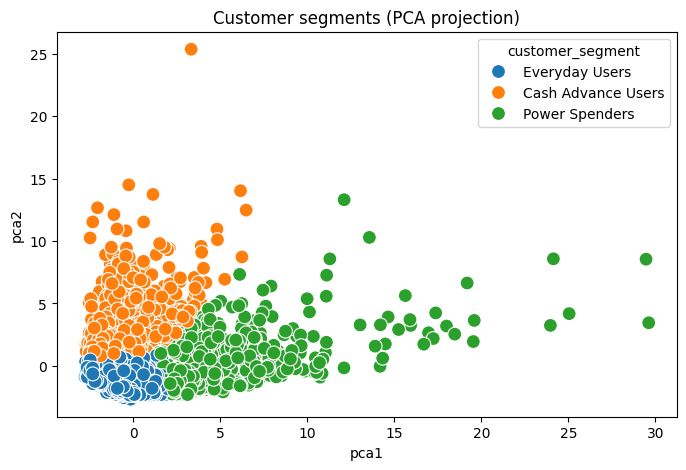

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="customer_segment",
    s=100
)

plt.title("Customer segments (PCA projection)")
plt.show()

### choosing number of clusters

In [30]:
features = df.drop(columns=["customer_segment"], errors="ignore")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

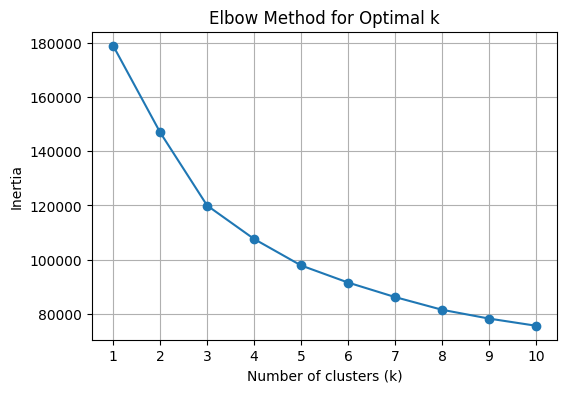

In [ ]:
# Use the elbow method to find the optimal number of clusters
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid()
plt.show()

In [39]:
# silhouette scores for different k values
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")


k=2, silhouette score=0.218
k=3, silhouette score=0.306
k=4, silhouette score=0.203
k=5, silhouette score=0.198
k=6, silhouette score=0.198


Both the elow method and the silhouette score show thar 3 clusters is optimal

In [40]:
features_activity = [
    "purchases",
    "purchases_frequency",
    "balance_frequency"
]

X_activity = df[features_activity]

scaler_activity = StandardScaler()
X_activity_scaled = scaler_activity.fit_transform(X_activity)

kmeans_activity = KMeans(n_clusters=3, random_state=42)
df["activity_cluster"] = kmeans_activity.fit_predict(X_activity_scaled)

df.groupby("activity_cluster")[features_activity].mean()

,purchases,purchases_frequency,balance_frequency
activity_cluster,,,
0,1466.999100,0.865182,0.965031
1,233.926961,0.149977,0.797736
2,12676.508231,0.919852,0.981385


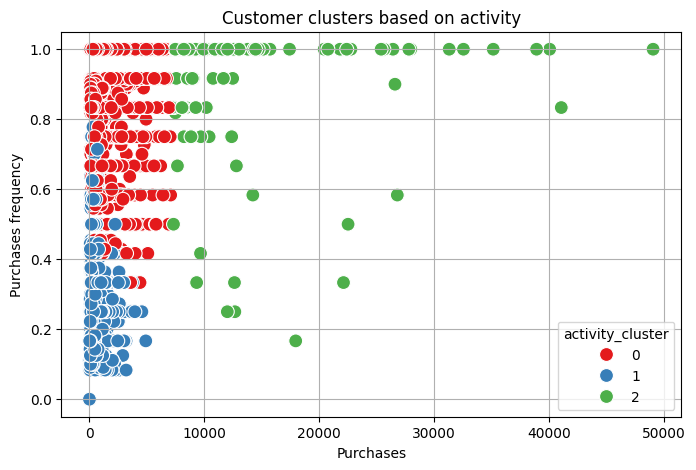

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="purchases",
    y="purchases_frequency",
    hue="activity_cluster",
    palette="Set1",
    s=100
)

plt.title("Customer clusters based on activity")
plt.xlabel("Purchases")
plt.ylabel("Purchases frequency")
plt.grid(True)
plt.show()

In [42]:
features_credit = [
    "cash_advance",
    "balance",
    "credit_limit"
]

X_credit = df[features_credit]

scaler_credit = StandardScaler()
X_credit_scaled = scaler_credit.fit_transform(X_credit)

kmeans_credit = KMeans(n_clusters=3, random_state=42)
df["credit_cluster"] = kmeans_credit.fit_predict(X_credit_scaled)

df.groupby("credit_cluster")[features_credit].mean()

,cash_advance,balance,credit_limit
credit_cluster,,,
0,458.717017,759.673642,2451.085409
1,767.123837,2030.091959,8172.532915
2,5392.927348,6258.237086,9671.287129


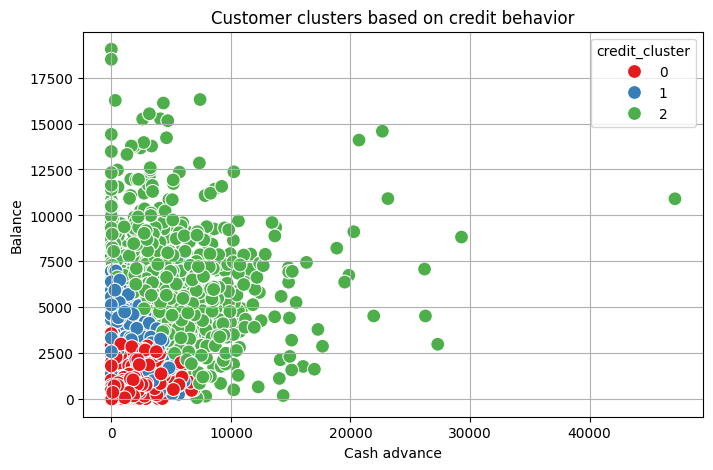

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="cash_advance",
    y="balance",
    hue="credit_cluster",
    palette="Set1",
    s=100
)

plt.title("Customer clusters based on credit behavior")
plt.xlabel("Cash advance")
plt.ylabel("Balance")
plt.grid(True)
plt.show()

In [44]:
features_purchase = [
    "purchases",
    "installments_purchases",
    "oneoff_purchases"
]

X_purchase = df[features_purchase]

scaler_purchase = StandardScaler()
X_purchase_scaled = scaler_purchase.fit_transform(X_purchase)

kmeans_purchase = KMeans(n_clusters=3, random_state=42)
df["purchase_cluster"] = kmeans_purchase.fit_predict(X_purchase_scaled)

df.groupby("purchase_cluster")[features_purchase].mean()

,purchases,installments_purchases,oneoff_purchases
purchase_cluster,,,
0,4798.635957,1915.185586,2884.226687
1,532.185656,238.364568,294.067981
2,27690.865833,6267.981250,21422.884583


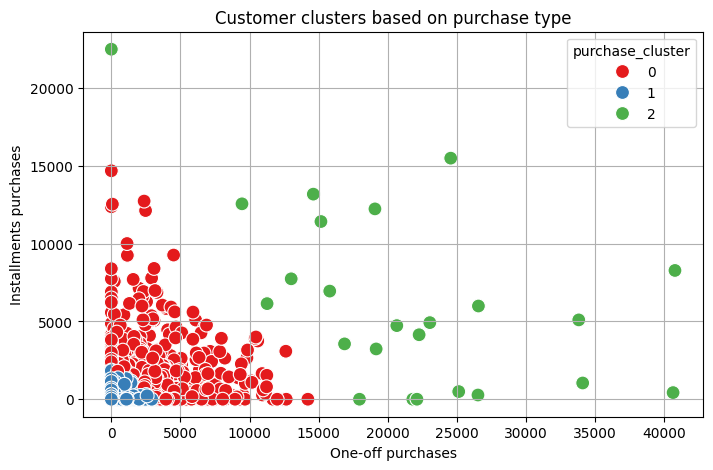

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="oneoff_purchases",
    y="installments_purchases",
    hue="purchase_cluster",
    palette="Set1",
    s=100
)

plt.title("Customer clusters based on purchase type")
plt.xlabel("One-off purchases")
plt.ylabel("Installments purchases")
plt.grid(True)
plt.show()

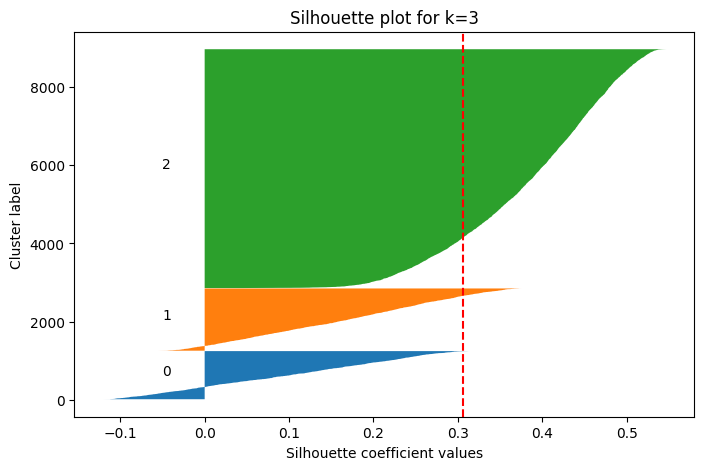

In [46]:
from sklearn.metrics import silhouette_samples, silhouette_score

# use the orginal model with all features to calculate silhouette scores and plot silhouette plot
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

plt.figure(figsize=(8,5))
y_lower = 10

for i in range(3):
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_values
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.title("Silhouette plot for k=3")
plt.show()